In [1]:
import os
import pandas as pd
import numpy as np
from concurrent import futures
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier,  GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from hiclass import LocalClassifierPerNode, LocalClassifierPerParentNode, LocalClassifierPerLevel

from patchOTDA.utils import EXAMPLE_DATA_, REF_DATA_, VISp_MET_nodes, VISp_T_nodes, \
    filter_MMS, find_outlier_idxs, param_grid_from_dict, select_by_col, not_select_by_col,\
CLASS_MODELS, HICLASS_METHOD, MMS_DATA

from patchOTDA.external import skada
from patchOTDA.domainAdapt import PatchClampOTDA
from functools import partial

import matplotlib.pyplot as plt
import joblib
%matplotlib inline

# --- Reproducibility & hyperparameter constants ---
RANDOM_STATE = 42
KNN_K = 5           # neighbors for KNNImputer
N_ITER = 100        # nevergrad tuning budget
N_JOBS = 5          # parallel workers for tuning
np.random.seed(RANDOM_STATE)

labels="VISp_T"
hiclass_method = "LocalClassifierPerNode"
class_model = "GradientBoostingClassifier"

In [2]:
#load in the CKTE_M1 and VISp_view datasets

SOURCE = "CTKE_M1"
TARGET = "VISp_Viewer"

ref_data = MMS_DATA[SOURCE]
ref_data_ephys, ref_data_meta = ref_data['ephys'], ref_data['meta']
Xs, Ys = ref_data_ephys, ref_data_meta[[labels+"_1_en", labels+"_2_en", labels+"_3_en"]]

data = MMS_DATA[TARGET]
data_ephys, data_meta = data['ephys'], data['meta']
data_ephys = data_ephys.loc[data_meta.index]
data_meta = data_meta.loc[data_ephys.index]
Xt, Yt = data_ephys, data_meta[[labels+"_1_en", labels+"_2_en", labels+"_3_en"]]

## Phase 1: Data Exploration & QC
Inspect class distributions at each hierarchical level for both source (VISp_Viewer) and target (CTKE_M1).  
**Important:** Label encoders are fit per-dataset independently we re-encode jointly to ensure compatible integer codes.

  Level 1 (Broad class): classes ONLY in source (cannot be evaluated on target): {'L4IT', 'L5PT', 'L5IT', 'L6IT', 'L6CT', 'Microglia', 'L2/3', 'L6b', 'L5NP'}
  Level 2 (Subtype): classes ONLY in source (cannot be evaluated on target): {'L5PT_PT', 'L6IT_IT', 'L6b_VISp', 'Microglia_Siglech', 'L6b_ALM', 'L2/3_IT', 'L4IT_IT', 'L6b_Hsd17b2', 'L5NP_NP', 'L6CT_CT', 'L6b_P2ry12', 'L5IT_IT'}
  Level 3 (Fine-grained): classes ONLY in source (cannot be evaluated on target): {'L6b_ALM_Olfr111', 'L6b_VISp_Crh', 'L6b_Hsd17b2', 'L6IT_IT_VISp', 'L5IT_IT_ALM', 'L4IT_IT_VISp', 'L5PT_PT_ALM', 'L2/3_IT_ALM', 'Microglia_Siglech', 'L6IT_IT_ALM', 'L2/3_IT_VISp', 'L5IT_IT_VISp', 'L6CT_CT_VISp', 'L5NP_NP_VISp', 'L5NP_NP_ALM', 'L6b_P2ry12', 'L5PT_PT_VISp', 'L6CT_CT_ALM', 'L6b_VISp_Col8a1', 'L6b_VISp_Mup5'}
  Level 3 (Fine-grained): classes ONLY in target (cannot be predicted by source-trained model): {'Vip_Igfbp6_Pltp'}

After filtering: Source 815 samples, Target 4258 samples


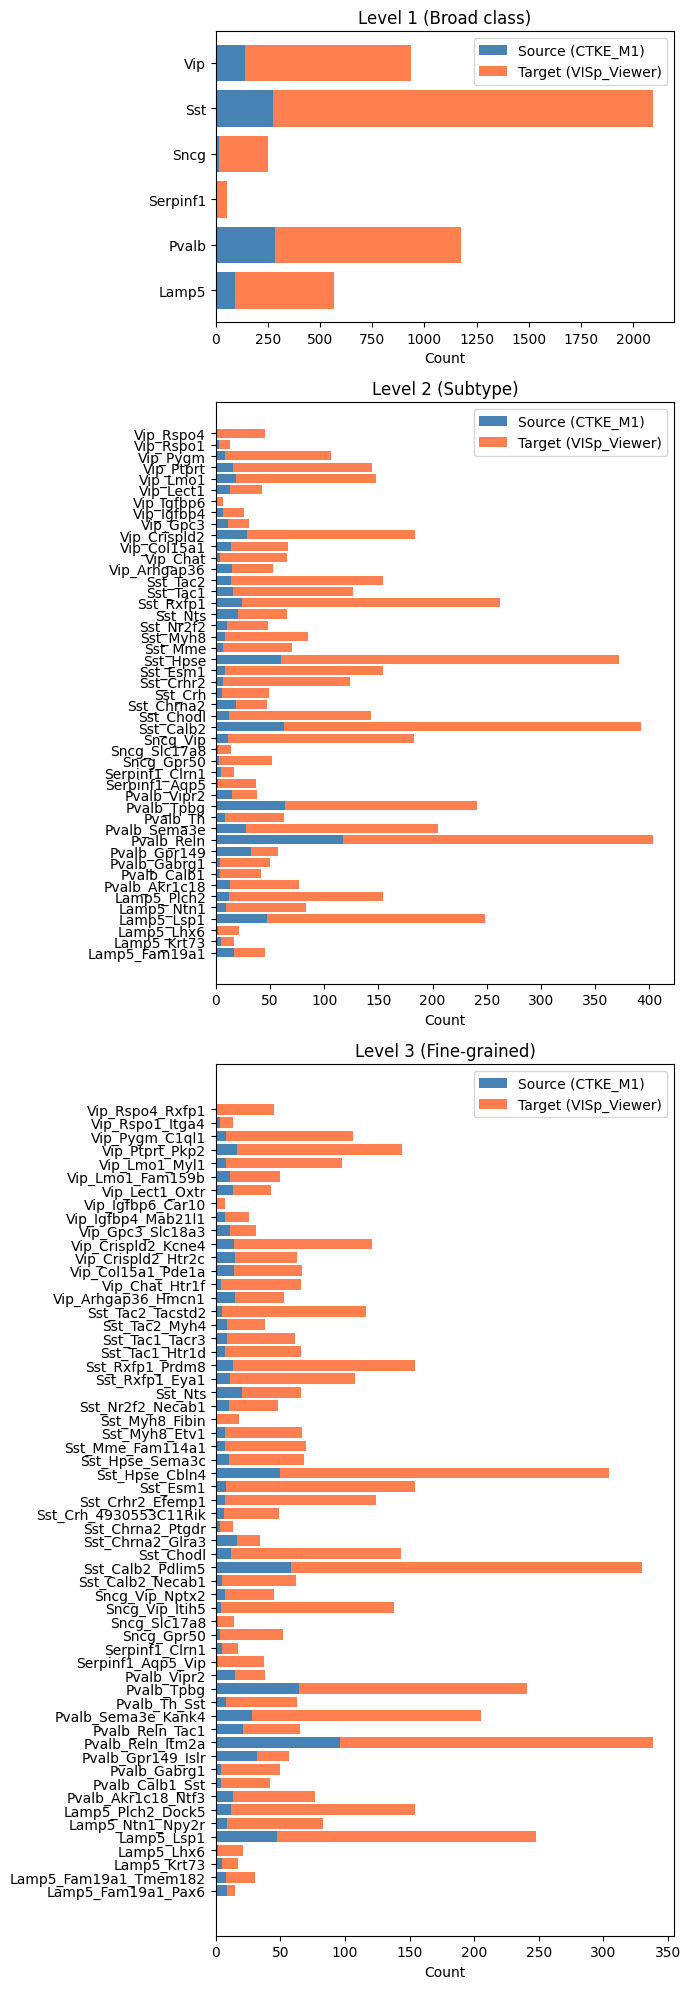

In [3]:
# --- Step 1: Joint label encoding & class distribution QC ---
# The per-dataset LabelEncoders may assign different integers to the same class name.
# We build joint encoders so source and target labels are directly comparable.

joint_le = {}  # {level: LabelEncoder}
Ys_arr = Ys.to_numpy()
Yt_arr = Yt.to_numpy()

for lvl in range(3):
    le_s = MMS_DATA[SOURCE][f'{labels}_LE_{lvl+1}']
    le_t = MMS_DATA[TARGET][f'{labels}_LE_{lvl+1}']
    # Decode both to strings
    Ys_str = le_s.inverse_transform(Ys_arr[:, lvl].astype(int))
    Yt_str = le_t.inverse_transform(Yt_arr[:, lvl].astype(int))
    # Fit a joint encoder on the union of class names
    all_classes = np.union1d(np.unique(Ys_str), np.unique(Yt_str))
    le_joint = LabelEncoder()
    le_joint.fit(all_classes)
    joint_le[lvl] = le_joint
    # Re-encode with joint encoder
    Ys_arr[:, lvl] = le_joint.transform(Ys_str)
    Yt_arr[:, lvl] = le_joint.transform(Yt_str)

# --- Class distribution & filtering ---
level_names = ['Level 1 (Broad class)', 'Level 2 (Subtype)', 'Level 3 (Fine-grained)']

# Report classes unique to one dataset
for lvl in range(3):
    s_classes = set(joint_le[lvl].inverse_transform(np.unique(Ys_arr[:, lvl].astype(int))))
    t_classes = set(joint_le[lvl].inverse_transform(np.unique(Yt_arr[:, lvl].astype(int))))
    only_source = s_classes - t_classes
    only_target = t_classes - s_classes
    if only_source:
        print(f"  {level_names[lvl]}: classes ONLY in source (cannot be evaluated on target): {only_source}")
    if only_target:
        print(f"  {level_names[lvl]}: classes ONLY in target (cannot be predicted by source-trained model): {only_target}")

# Filter to common classes — compute masks per level INDEPENDENTLY on the
# original arrays, then intersect, so no level's filtering compounds onto another.
s_keep = np.ones(len(Ys_arr), dtype=bool)
t_keep = np.ones(len(Yt_arr), dtype=bool)

for lvl in range(3):
    le_j = joint_le[lvl]
    s_classes = set(le_j.inverse_transform(np.unique(Ys_arr[:, lvl].astype(int))))
    t_classes = set(le_j.inverse_transform(np.unique(Yt_arr[:, lvl].astype(int))))
    common_classes = s_classes.intersection(t_classes)
    common_codes = le_j.transform(list(common_classes))
    s_keep &= np.isin(Ys_arr[:, lvl].astype(int), common_codes)
    t_keep &= np.isin(Yt_arr[:, lvl].astype(int), common_codes)

# Apply combined mask once
Xs = Xs[s_keep]
Xt = Xt[t_keep]
Ys = Ys[s_keep]
Yt = Yt[t_keep]
Ys_arr = Ys_arr[s_keep]
Yt_arr = Yt_arr[t_keep]

print(f"\nAfter filtering: Source {Ys_arr.shape[0]} samples, Target {Yt_arr.shape[0]} samples")

# --- Class distribution plots (post-filter) ---
fig, axes = plt.subplots(3, 1, figsize=(7, 20), height_ratios=[1,2,3])

for lvl in range(3):
    le_j = joint_le[lvl]
    ax = axes[lvl]
    s_codes, s_counts = np.unique(Ys_arr[:, lvl].astype(int), return_counts=True)
    t_codes, t_counts = np.unique(Yt_arr[:, lvl].astype(int), return_counts=True)

    all_codes = np.union1d(s_codes, t_codes)
    class_names = le_j.inverse_transform(all_codes)
    s_count_map = dict(zip(s_codes, s_counts))
    t_count_map = dict(zip(t_codes, t_counts))
    s_vals = np.array([s_count_map.get(c, 0) for c in all_codes])
    t_vals = np.array([t_count_map.get(c, 0) for c in all_codes])

    y_pos = np.arange(len(class_names))
    ax.barh(y_pos, s_vals, color='steelblue', label=f'Source ({SOURCE})')
    ax.barh(y_pos, t_vals, left=s_vals, color='coral', label=f'Target ({TARGET})')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(class_names)
    ax.set_title(level_names[lvl])
    ax.set_xlabel('Count')
    ax.legend()

fig.tight_layout()
plt.show()

In [4]:
#check the feature columns of the two datasets, and find the common features
print(f"{SOURCE} features:", Xs.columns)
print(f"{TARGET} features:", Xt.columns)
common_features = Xs.columns.intersection(Xt.columns)
print("Common features:", common_features)

CTKE_M1 features: Index(['AP Fano factor', 'AP amplitude (mV)', 'AP amplitude adaptation index',
       'AP amplitude average adaptation index', 'AP coefficient of variation',
       'AP threshold (mV)', 'AP width (ms)', 'Afterdepolarization (mV)',
       'Burstiness', 'ISI Fano factor', 'ISI average adaptation index',
       'ISI coefficient of variation', 'Input resistance (MΩ)', 'Latency (ms)',
       'Latency @ +20pA current (ms)', 'Rebound (mV)', 'Rebound APs (number)',
       'Resting membrane potential (mV)', 'Rheobase (pA)', 'Sag area (mV*s)',
       'Sag ratio', 'Sag time (s)', 'Wildness'],
      dtype='object')
VISp_Viewer features: Index(['AP amplitude (mV)', 'AP threshold (mV)', 'AP width (ms)',
       'Adaptation ratio', 'After hyperpolarization (mV)', 'Avg ISI',
       'F I curve slope', 'Fast trough V (long square) (millivolts)',
       'Fast trough V (ramp) (millivolts)',
       'Fast trough V (short square) (millivolts)', 'Input resistance (MΩ)',
       'Peak V (long s

In [5]:
# Preprocess: common features, imputation, scaling
# NOTE: Imputer and scaler are fit on the CONCATENATION of source + target so that
# both domains share the same feature statistics. This is standard for unsupervised 
# domain adaptation where we have access to unlabeled target features at training time.
Xs_common = Xs[common_features]
Xt_common = Xt[common_features]

X_all = pd.concat([Xs_common, Xt_common], axis=0)

impute_and_scale_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=KNN_K)),
    ('scaler', StandardScaler())
])
X_all_processed = impute_and_scale_pipeline.fit_transform(X_all)
Xs_preprocessed = X_all_processed[:len(Xs_common)]
Xt_preprocessed = X_all_processed[len(Xs_common):]

# Sanity check: feature matrices and label arrays must have matching row counts
assert Xs_preprocessed.shape[0] == Ys_arr.shape[0], f"Source mismatch: X={Xs_preprocessed.shape[0]}, Y={Ys_arr.shape[0]}"
assert Xt_preprocessed.shape[0] == Yt_arr.shape[0], f"Target mismatch: X={Xt_preprocessed.shape[0]}, Y={Yt_arr.shape[0]}"
print(f"Source: {Xs_preprocessed.shape[0]} samples, Target: {Xt_preprocessed.shape[0]} samples — shapes OK")

# --- Target train/test split ---
# Split target into train (used for OT fitting) and test (held-out for evaluation).
# This diagnoses whether OT transport overfits to the target distribution.
# Stratify on Level 1 labels (broadest class) to preserve class balance.
TEST_SIZE = 0.3

Xt_train, Xt_test, Yt_train_arr, Yt_test_arr, train_idx, test_idx = train_test_split(
    Xt_preprocessed, Yt_arr, np.arange(len(Yt_arr)),
    test_size=TEST_SIZE, stratify=Yt_arr[:, 0], random_state=RANDOM_STATE
)

Xs_train, Xs_test, Ys_train_arr, Ys_test_arr, train_idx, test_idx = train_test_split(
    Xs_preprocessed, Ys_arr, np.arange(len(Ys_arr)),
    test_size=TEST_SIZE, stratify=Ys_arr[:, 0], random_state=RANDOM_STATE
)

print(f"\nTarget split: train={Xt_train.shape[0]}, test={Xt_test.shape[0]} (test_size={TEST_SIZE})")
# Verify stratification preserved Level 1 class proportions
for label_name in ['train', 'test']:
    arr = Yt_train_arr if label_name == 'train' else Yt_test_arr
    codes, counts = np.unique(arr[:, 0].astype(int), return_counts=True)
    props = counts / counts.sum()
    names = joint_le[0].inverse_transform(codes)
    print(f"  {label_name} L1 proportions: { {n: f'{p:.2f}' for n, p in zip(names, props)} }")

Source: 815 samples, Target: 4258 samples — shapes OK

Target split: train=2980, test=1278 (test_size=0.3)
  train L1 proportions: {'Lamp5': '0.11', 'Pvalb': '0.21', 'Serpinf1': '0.01', 'Sncg': '0.05', 'Sst': '0.43', 'Vip': '0.19'}
  test L1 proportions: {'Lamp5': '0.11', 'Pvalb': '0.21', 'Serpinf1': '0.01', 'Sncg': '0.05', 'Sst': '0.43', 'Vip': '0.19'}


In [6]:
# OT tuning — set seed for nevergrad reproducibility
# OT is fit using ONLY the target TRAIN split; test is held out for evaluation.
np.random.seed(RANDOM_STATE)
da_flex = PatchClampOTDA(flexible_transporter=False)
#da_flex.tune(Xs_preprocessed, Xt_train, n_iter=N_ITER, n_jobs=N_JOBS, method='unidirectional', verbose=2)
Xs_flex = da_flex.fit_transform(Xs_preprocessed, Xt_train)
Xs_train_flex = da_flex.transform(Xs_train, Xt_train) #Certain DA methods do no support transforming new data after fitting, but if supported we should use the same transformation on the train/test splits as on the full source.
Xs_test_flex = da_flex.transform(Xs_test, Xt_train)

## Feature Distribution: Before vs After Domain Adaptation
PCA projections showing source/target overlap before and after OT transport.  
**Train-target** (×) was used for OT fitting; **test-target** (△) was held out.  
Points colored by Level 1 label (excitatory / inhibitory).

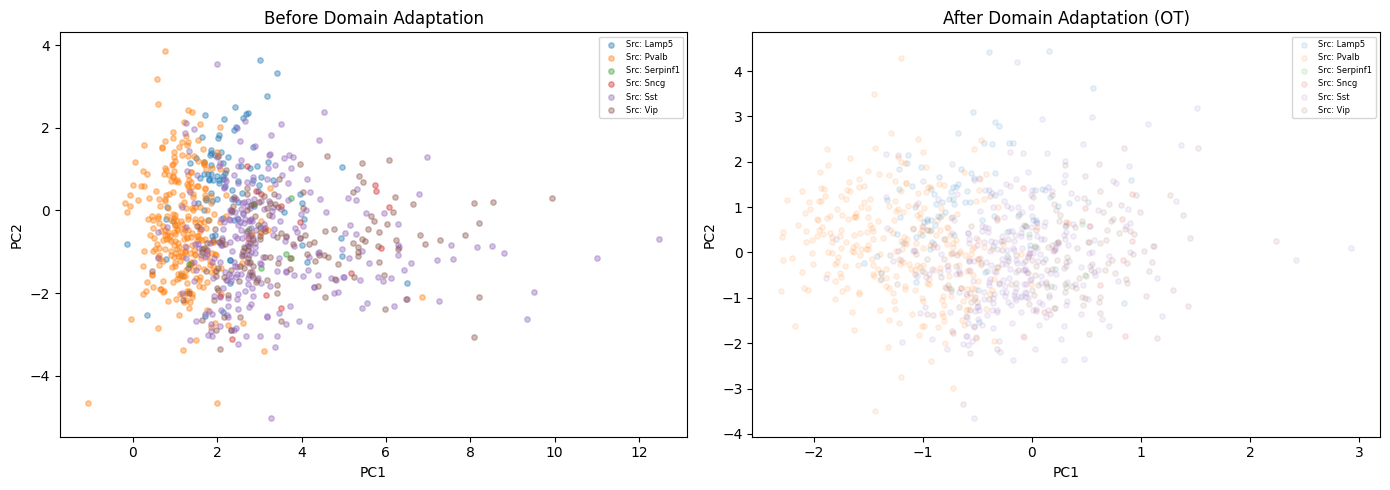

In [7]:
# --- Step 2: PCA visualization — before vs after DA ---
# PCA is fit ONCE on the pre-DA data so both panels share the same coordinate system.
# Train-target shown as × markers, test-target shown as △ markers.
from sklearn.decomposition import SparsePCA

pca = SparsePCA(n_components=2, random_state=RANDOM_STATE)

# Level-1 string labels for coloring (use joint encoder on filtered arrays)
Ys_l1_str = joint_le[0].inverse_transform(Ys_arr[:, 0].astype(int))
Yt_l1_str = joint_le[0].inverse_transform(Yt_arr[:, 0].astype(int))
Yt_train_l1_str = Yt_l1_str[train_idx]
Yt_test_l1_str = Yt_l1_str[test_idx]
unique_classes = np.unique(np.concatenate([Ys_l1_str, Yt_l1_str]))
cmap = {c: plt.cm.tab10(i) for i, c in enumerate(unique_classes)}

# Fit PCA on pre-DA data (shared basis for both panels)
X_both_before = np.vstack([Xs_preprocessed, Xt_preprocessed])
pca.fit(X_both_before)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE DA
pc_s_before = pca.transform(Xs_preprocessed)
pc_t_train_before = pca.transform(Xt_train)
pc_t_test_before = pca.transform(Xt_test)

ax = axes[0]
ax.set_title('Before Domain Adaptation')
for cls in unique_classes:
    mask_s = Ys_l1_str == cls
    mask_train = Yt_train_l1_str == cls
    mask_test = Yt_test_l1_str == cls
    ax.scatter(pc_s_before[mask_s, 0], pc_s_before[mask_s, 1],
               c=[cmap[cls]], marker='o', alpha=0.4, label=f'Src: {cls}', s=15)
    # ax.scatter(pc_t_train_before[mask_train, 0], pc_t_train_before[mask_train, 1],
    #            c=[cmap[cls]], marker='x', alpha=0.4, label=f'Tgt train: {cls}', s=15)
    # ax.scatter(pc_t_test_before[mask_test, 0], pc_t_test_before[mask_test, 1],
    #            c=[cmap[cls]], marker='^', alpha=0.6, label=f'Tgt test: {cls}', s=25)
ax.legend(fontsize=6, loc='best')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# AFTER DA — same PCA basis, only source changes
pc_s_after = pca.transform(Xs_flex)

ax = axes[1]
ax.set_title('After Domain Adaptation (OT)')
for cls in unique_classes:
    mask_s = Ys_l1_str == cls
    mask_train = Yt_train_l1_str == cls
    mask_test = Yt_test_l1_str == cls
    ax.scatter(pc_s_after[mask_s, 0], pc_s_after[mask_s, 1],
               c=[cmap[cls]], marker='o', alpha=0.1, label=f'Src: {cls}', s=15)
    # ax.scatter(pc_t_train_before[mask_train, 0], pc_t_train_before[mask_train, 1],
    #            c=[cmap[cls]], marker='x', alpha=0.4, label=f'Tgt train: {cls}', s=15)
    # ax.scatter(pc_t_test_before[mask_test, 0], pc_t_test_before[mask_test, 1],
    #            c=[cmap[cls]], marker='^', alpha=0.8, label=f'Tgt test: {cls}', s=25)
ax.legend(fontsize=6, loc='best')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

fig.tight_layout()
plt.show()

## Phase 2: Baseline — No Domain Adaptation
Train a hierarchical classifier on the raw preprocessed source data and predict on **both** target splits.  
Comparing train-target vs test-target accuracy in the baseline establishes whether the split itself introduces a gap.

In [8]:
# --- Step 3: Baseline hierarchical classifier (no DA) ---
import logging as _logging


def safe_inverse_transform(le, codes):
    """Decode integer codes; warn and label any code outside the encoder's known set."""
    lookup = {i: name for i, name in enumerate(le.classes_)}
    result = []
    unknown_codes = set()
    for c in codes:
        if c in lookup:
            result.append(lookup[c])
        else:
            unknown_codes.add(c)
            result.append(f"Unknown({c})")
    if unknown_codes:
        _logging.warning(f"Predicted codes not in encoder: {unknown_codes}")
    return np.array(result)
# suppress warnings from safe_inverse_transform for cleaner output


_logging.getLogger().setLevel(_logging.ERROR) #supress hiclass warnings for cleaner output
baseline_clf = LocalClassifierPerNode(
    local_classifier=HistGradientBoostingClassifier(random_state=RANDOM_STATE), verbose=0,
)
baseline_clf.fit(Xt_train, Yt_train_arr)


# Predict on target train set as a sanity check (should have reasonable performance since it's the same distribution)
Yt_pred_source_test = baseline_clf.predict(Xt_train)
source_test_acc = accuracy_score(Yt_train_arr[:, 0].astype(int), Yt_pred_source_test[:, 0].astype(int))
print(f"Baseline accuracy on TARGET train set (sanity check): {source_test_acc:.4f}")

# Predict on both target splits
Yt_pred_baseline_train = baseline_clf.predict(Xt_train)
Yt_pred_baseline_test = baseline_clf.predict(Xt_test)

# Predict on both source
Ys_pred_baseline_train = baseline_clf.predict(Xs_train)
Ys_pred_baseline_test = baseline_clf.predict(Xs_test)

# Predict on full Xs_preprocessed for later comparison with DA predictions
Ys_pred_baseline_full = baseline_clf.predict(Xs_preprocessed)

_logging.getLogger().setLevel(_logging.INFO) #restore logging
print("Baseline predictions — train source:", Ys_pred_baseline_train.shape, "test source:", Ys_pred_baseline_test.shape)
print("Baseline predictions — train target:", Yt_pred_baseline_train.shape, "test target:", Yt_pred_baseline_test.shape)
print("Sample predictions on TEST source (first 5):")
for lvl in range(3):
    decoded = safe_inverse_transform(joint_le[lvl], Ys_pred_baseline_test[:5, lvl].astype(int))
    print(f"  Level {lvl+1}: {decoded}")

Baseline accuracy on TARGET train set (sanity check): 0.9846
Baseline predictions — train source: (570, 3) test source: (245, 3)
Baseline predictions — train target: (2980, 3) test target: (1278, 3)
Sample predictions on TEST source (first 5):
  Level 1: ['Sst' 'Sst' 'Sst' 'Sncg' 'Sst']
  Level 2: ['Sst_Tac2' 'Sst_Tac2' 'Sst_Chodl' 'Sncg_Vip' 'Sst_Calb2']
  Level 3: ['Sst_Tac2_Tacstd2' 'Sst_Tac2_Tacstd2' 'Sst_Chodl' 'Sncg_Vip_Nptx2'
 'Sst_Calb2_Pdlim5']


In [9]:
# --- Step 4: Evaluate baseline on train-target and test-target ---
def evaluate_per_level(y_true, y_pred, joint_le, label=""):
    """Compute per-level metrics and return a summary DataFrame."""
    rows = []
    for lvl in range(y_true.shape[1]):
        yt = y_true[:, lvl].astype(int)
        yp = y_pred[:, lvl].astype(int)
        n = len(yt)
        n_classes = len(np.unique(yt))
        rows.append({
            'Level': f'Level {lvl+1}',
            'N': n,
            'Classes': n_classes,
            'Accuracy': accuracy_score(yt, yp),
            'Balanced Accuracy': balanced_accuracy_score(yt, yp),
            'F1 (macro)': f1_score(yt, yp, average='macro', zero_division=0),
        })
    df = pd.DataFrame(rows).set_index('Level')
    df.columns.name = label
    return df

baseline_train_results = evaluate_per_level(Ys_train_arr, Ys_pred_baseline_train, joint_le, label="Baseline Train-Source")
baseline_test_results = evaluate_per_level(Ys_test_arr, Ys_pred_baseline_test, joint_le, label="Baseline Test-Source")

baseline_target_train_results = evaluate_per_level(Yt_train_arr, Yt_pred_baseline_train, joint_le, label="Baseline Train-Target")
baseline_target_test_results = evaluate_per_level(Yt_test_arr, Yt_pred_baseline_test, joint_le, label="Baseline Test-Target")

print("=== Baseline Results — Train Source (OT saw this data) ===")
display(baseline_train_results)
print("\n=== Baseline Results — Test Source (held out from OT) ===")
display(baseline_test_results)

print("=== Baseline Results — Train Target (OT saw this data) ===")
display(baseline_target_train_results)
print("\n=== Baseline Results — Test Target (held out from OT) ===")
display(baseline_target_test_results)

=== Baseline Results — Train Source (OT saw this data) ===


Baseline Train-Source,N,Classes,Accuracy,Balanced Accuracy,F1 (macro)
Level,,,,,
Level 1,570,6,0.298246,0.227268,0.178816
Level 2,570,46,0.047368,0.034820,0.015509
Level 3,570,58,0.042105,0.034895,0.011709



=== Baseline Results — Test Source (held out from OT) ===


Baseline Test-Source,N,Classes,Accuracy,Balanced Accuracy,F1 (macro)
Level,,,,,
Level 1,245,6,0.281633,0.175523,0.146335
Level 2,245,43,0.032653,0.036268,0.011132
Level 3,245,54,0.028571,0.024436,0.008480


=== Baseline Results — Train Target (OT saw this data) ===


Baseline Train-Target,N,Classes,Accuracy,Balanced Accuracy,F1 (macro)
Level,,,,,
Level 1,2980,6,0.984564,0.987376,0.989457
Level 2,2980,47,0.980537,0.960623,0.960808
Level 3,2980,59,0.968121,0.915009,0.911648



=== Baseline Results — Test Target (held out from OT) ===


Baseline Test-Target,N,Classes,Accuracy,Balanced Accuracy,F1 (macro)
Level,,,,,
Level 1,1278,6,0.697966,0.500572,0.504946
Level 2,1278,47,0.301252,0.158933,0.154418
Level 3,1278,59,0.258216,0.131204,0.126337


## Phase 3: DA + Hierarchical Classification
Train the same hierarchical classifier on the OT-transported source data and predict on **both** target splits.  
If train-target accuracy >> test-target accuracy → OT is overfitting to the target distribution used during alignment.

In [11]:
# --- Step 5: DA-corrected hierarchical classifier ---
_logging.getLogger().setLevel(_logging.ERROR) #supress hiclass warnings for cleaner output
da_clf = LocalClassifierPerParentNode(
    local_classifier=HistGradientBoostingClassifier(random_state=RANDOM_STATE),
)
da_clf.fit(Xt_train, Yt_train_arr)  # Train on target

# Predict on both target splits
Yt_pred_da_train = da_clf.predict(Xt_train)
Yt_pred_da_test = da_clf.predict(Xt_test)

# Predict on both source
Ys_pred_da = da_clf.predict(Xs_flex)
Ys_pred_da_train = da_clf.predict(Xs_train_flex) #Not all DA methods support transforming new data after fitting, but if supported we should use the same transformation on the train/test splits as on the full source.
Ys_pred_da_test = da_clf.predict(Xs_test_flex)
_logging.getLogger().setLevel(_logging.INFO) #restore logging
print("DA predictions — train target:", Yt_pred_da_train.shape, "test target:", Yt_pred_da_test.shape)
print("DA predictions — train source:", Ys_pred_da_train.shape, "test source:", Ys_pred_da_test.shape)
print("Sample predictions on TEST target (first 5):")
for lvl in range(3):
    decoded = safe_inverse_transform(joint_le[lvl], Ys_pred_da[:5, lvl].astype(int))
    print(f"  Level {lvl+1}: {decoded}")

DA predictions — train target: (2980, 3) test target: (1278, 3)
DA predictions — train source: (570, 3) test source: (245, 3)
Sample predictions on TEST target (first 5):
  Level 1: ['Sst' 'Sst' 'Sst' 'Pvalb' 'Pvalb']
  Level 2: ['Sst_Hpse' 'Sst_Rxfp1' 'Sst_Tac2' 'Pvalb_Reln' 'Pvalb_Reln']
  Level 3: ['Sst_Hpse_Cbln4' 'Sst_Rxfp1_Prdm8' 'Sst_Tac2_Tacstd2' 'Pvalb_Reln_Tac1'
 'Pvalb_Reln_Itm2a']


In [12]:
# --- Step 6: Evaluate DA classifier on train-target and test-target ---
da_train_results = evaluate_per_level(Ys_train_arr, Ys_pred_da_train, joint_le, label="DA full")
da_test_results = evaluate_per_level(Ys_test_arr, Ys_pred_da_test, joint_le, label="DA Test-Source")

print("=== DA Results — Train Source (OT saw this data) ===")
display(da_train_results)
print("\n=== DA Results — Test Source (held out from OT) ===")
display(da_test_results)

=== DA Results — Train Source (OT saw this data) ===


/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


DA full,N,Classes,Accuracy,Balanced Accuracy,F1 (macro)
Level,,,,,
Level 1,570,6,0.578947,0.398949,0.402778
Level 2,570,46,0.177193,0.086886,0.075880
Level 3,570,58,0.154386,0.067699,0.059902



=== DA Results — Test Source (held out from OT) ===


DA Test-Source,N,Classes,Accuracy,Balanced Accuracy,F1 (macro)
Level,,,,,
Level 1,245,6,0.559184,0.371668,0.383948
Level 2,245,43,0.171429,0.082641,0.063452
Level 3,245,54,0.142857,0.057906,0.043907


## Phase 4: Diagnostic Comparison
4-condition comparison: {Baseline, DA} × {Train Target, Test Target}.  
- **Δ columns**: DA improvement over Baseline for each split.  
- **DA Train-Test Gap**: If positive, DA metrics are better on train-target than test-target → evidence of overfitting.

In [13]:
# --- Step 7: Comparative summary table (4 conditions) ---
# Join all 4 result DataFrames: {Baseline, DA} × {Train Target, Test Target}
comparison = (
    baseline_train_results
    .join(baseline_test_results, lsuffix=' (BL-Train)', rsuffix=' (BL-Test)')
    .join(da_train_results.add_suffix(' (DA-Train)'))
    .join(da_test_results.add_suffix(' (DA-Test)'))
)

# Compute deltas: DA improvement over Baseline for each split
delta_cols = []
for split in ['Train', 'Test']:
    for metric in ['Accuracy', 'Balanced Accuracy', 'F1 (macro)']:
        col = f'Δ {metric} ({split})'
        comparison[col] = comparison[f'{metric} (DA-{split})'] - comparison[f'{metric} (BL-{split})']
        delta_cols.append(col)

# Also compute train-vs-test gap for DA (overfitting diagnostic)
for metric in ['Accuracy', 'Balanced Accuracy', 'F1 (macro)']:
    col = f'DA Train-Test Gap ({metric})'
    comparison[col] = comparison[f'{metric} (DA-Train)'] - comparison[f'{metric} (DA-Test)']
    delta_cols.append(col)

delta_abs_max = max(comparison[delta_cols].abs().max().max(), 0.01)

print("=== Full Comparison: {Baseline, DA} × {Train Target, Test Target} ===")
print("Δ columns = DA - Baseline for each split. 'DA Train-Test Gap' = overfitting diagnostic.")
display(comparison.style.format("{:.3f}").background_gradient(
    subset=delta_cols,
    cmap='RdYlGn', vmin=-delta_abs_max, vmax=delta_abs_max
))

=== Full Comparison: {Baseline, DA} × {Train Target, Test Target} ===
Δ columns = DA - Baseline for each split. 'DA Train-Test Gap' = overfitting diagnostic.


,N (BL-Train),Classes (BL-Train),Accuracy (BL-Train),Balanced Accuracy (BL-Train),F1 (macro) (BL-Train),N (BL-Test),Classes (BL-Test),Accuracy (BL-Test),Balanced Accuracy (BL-Test),F1 (macro) (BL-Test),N (DA-Train),Classes (DA-Train),Accuracy (DA-Train),Balanced Accuracy (DA-Train),F1 (macro) (DA-Train),N (DA-Test),Classes (DA-Test),Accuracy (DA-Test),Balanced Accuracy (DA-Test),F1 (macro) (DA-Test),Δ Accuracy (Train),Δ Balanced Accuracy (Train),Δ F1 (macro) (Train),Δ Accuracy (Test),Δ Balanced Accuracy (Test),Δ F1 (macro) (Test),DA Train-Test Gap (Accuracy),DA Train-Test Gap (Balanced Accuracy),DA Train-Test Gap (F1 (macro))
Level,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Level 1,570.000,6.000,0.298,0.227,0.179,245.000,6.000,0.282,0.176,0.146,570.000,6.000,0.579,0.399,0.403,245.000,6.000,0.559,0.372,0.384,0.281,0.172,0.224,0.278,0.196,0.238,0.020,0.027,0.019
Level 2,570.000,46.000,0.047,0.035,0.016,245.000,43.000,0.033,0.036,0.011,570.000,46.000,0.177,0.087,0.076,245.000,43.000,0.171,0.083,0.063,0.130,0.052,0.060,0.139,0.046,0.052,0.006,0.004,0.012
Level 3,570.000,58.000,0.042,0.035,0.012,245.000,54.000,0.029,0.024,0.008,570.000,58.000,0.154,0.068,0.060,245.000,54.000,0.143,0.058,0.044,0.112,0.033,0.048,0.114,0.033,0.035,0.012,0.010,0.016


/tmp/ipykernel_3262502/518142337.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


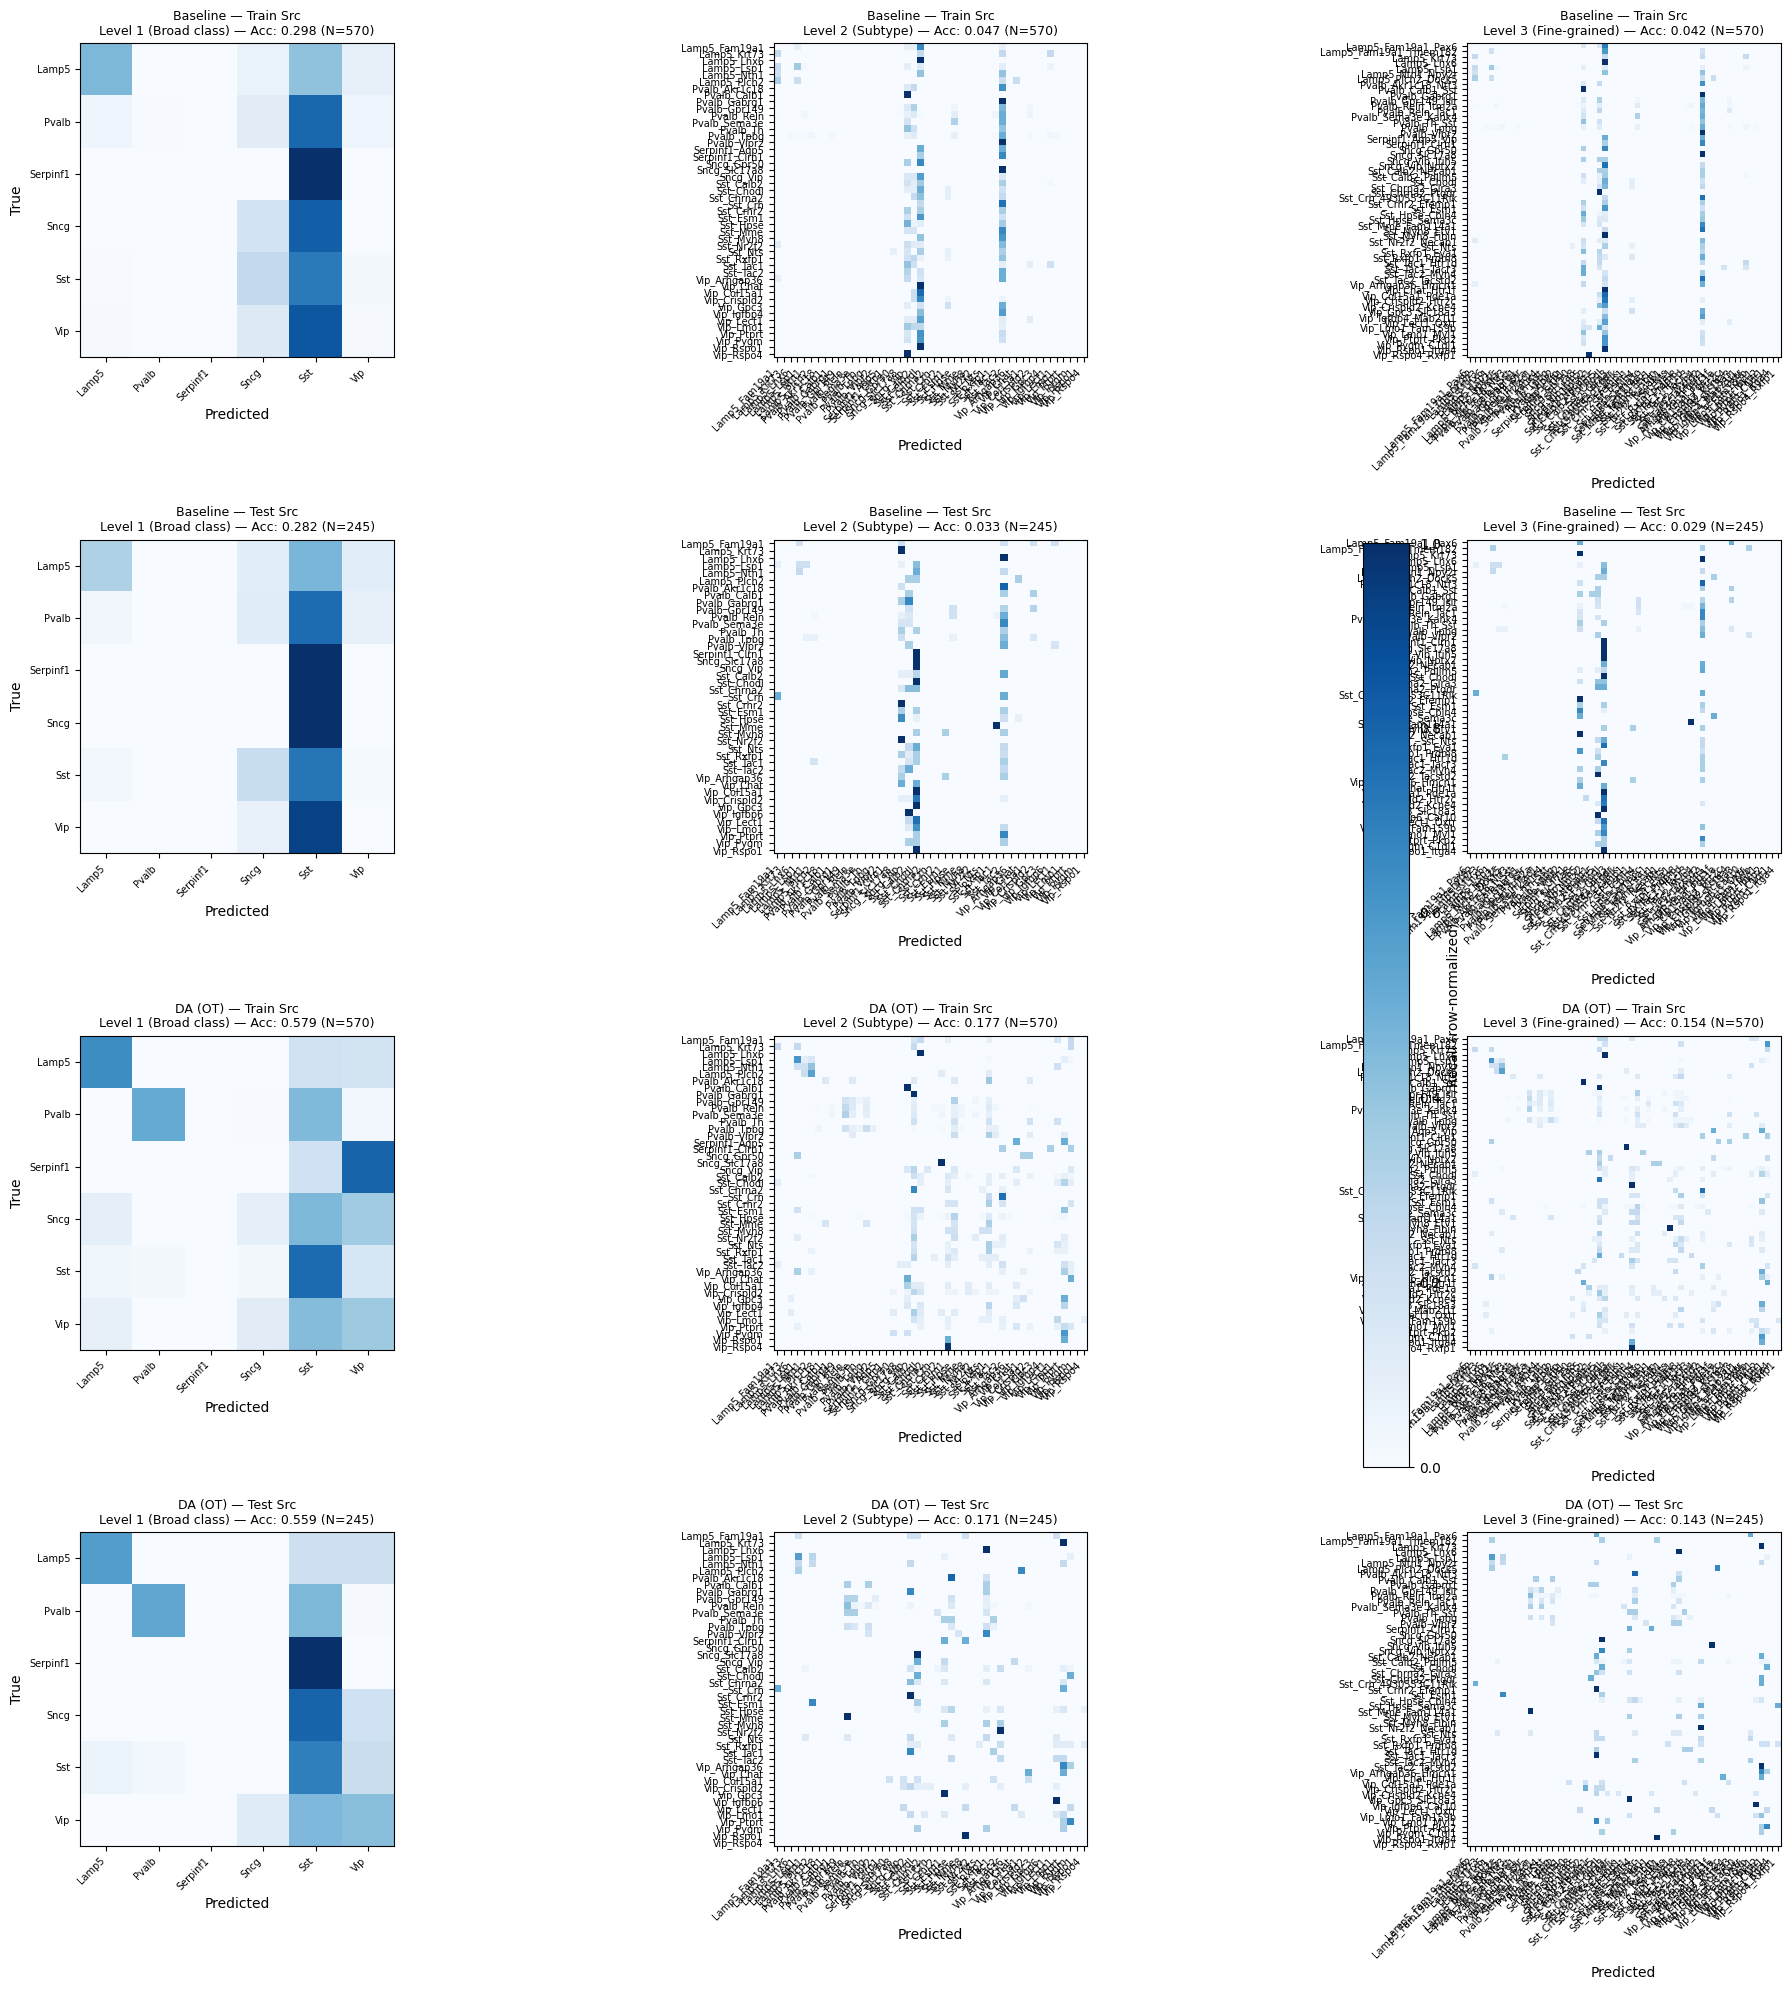

In [14]:
# --- Step 8: Confusion matrix grid (4×3): {Baseline, DA} × {Train, Test} × 3 levels ---
level_names = ['Level 1 (Broad class)', 'Level 2 (Subtype)', 'Level 3 (Fine-grained)']

conditions = [
    (Ys_pred_baseline_train, Ys_train_arr, 'Baseline — Train Src'),
    (Ys_pred_baseline_test,  Ys_test_arr,  'Baseline — Test Src'),
    (Ys_pred_da_train,       Ys_train_arr, 'DA (OT) — Train Src'),
    (Ys_pred_da_test,        Ys_test_arr,  'DA (OT) — Test Src'),
]

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

for row, (y_pred, y_true, method_name) in enumerate(conditions):
    for lvl in range(3):
        ax = axes[row, lvl]
        yt = y_true[:, lvl].astype(int)
        yp = y_pred[:, lvl].astype(int)

        all_labels = np.union1d(yt, yp)
        known_labels = np.array([c for c in all_labels if c < len(joint_le[lvl].classes_)])
        class_names = joint_le[lvl].inverse_transform(known_labels)

        known_mask = np.isin(yt, known_labels) & np.isin(yp, known_labels)
        cm = confusion_matrix(yt[known_mask], yp[known_mask], labels=known_labels, normalize='true')
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
        ax.set_yticklabels(class_names, fontsize=7)

        acc = accuracy_score(yt[known_mask], yp[known_mask])
        ax.set_title(f'{method_name}\n{level_names[lvl]} — Acc: {acc:.3f} (N={known_mask.sum()})', fontsize=9)
        ax.set_ylabel('True') if lvl == 0 else None
        ax.set_xlabel('Predicted')

fig.colorbar(im, ax=axes, shrink=0.6, label='Recall (row-normalized)')
fig.tight_layout()
plt.show()